In [1]:
import sys
import torch
sys.path.insert(0, r"d:\VS codes\ML Coding")

import configs.config as cfg
from model.detector       import build_detector
from dataset.coco_dataset import (COCODataset, collate_fn,
                                   LABEL_TO_NAME, COCO_ID_TO_LABEL)
from dataset.transforms   import get_val_transforms
from torch.utils.data     import DataLoader, Subset
from training.evaluator   import (evaluate_one_epoch,
                                   format_eval_summary)
from utils.metrics        import compute_map

device = torch.device(cfg.DEVICE)
print(f"Device  : {device}")
print(f"Imports : OK")

Device  : cpu
Imports : OK


In [4]:
import os
from torch.utils.data import DataLoader, Subset
from dataset.coco_dataset import COCODataset, collate_fn
from dataset.transforms   import get_val_transforms

# Get list of images that actually exist in your folder
existing_images = set(os.listdir(cfg.VAL_IMG_DIR))
print(f"Images in folder: {len(existing_images)}")

# Build val dataset using TRAIN annotation
# (your filtered images are from train set)
val_ds = COCODataset(
    cfg.TRAIN_IMG_DIR,
    cfg.TRAIN_ANN,       # use train annotations — your images are from here
    transforms = get_val_transforms()
)

# Filter dataset to only indices where image actually exists
valid_indices = []
for i, img_id in enumerate(val_ds.img_ids):
    img_info  = val_ds.coco.loadImgs(img_id)[0]
    file_name = img_info["file_name"]
    if file_name in existing_images:
        valid_indices.append(i)

print(f"Valid indices found : {len(valid_indices)}")

# Use first 20 valid images for sanity check
small_val  = Subset(val_ds, valid_indices[:20])
val_loader = DataLoader(
    small_val,
    batch_size  = 1,
    shuffle     = False,
    collate_fn  = collate_fn,
    num_workers = 0,
)

print(f"Val subset size : {len(small_val)} images")
print(f"Ready!")

Images in folder: 70081
  Loading annotations from D:\VS codes\ML Coding\People_vehicles dataset\annotations\annotations_trainval2017\annotations\instances_train2017.json ...
loading annotations into memory...
Done (t=16.71s)
creating index...
index created!
  Found 70082 images with target classes
Valid indices found : 70081
Val subset size : 20 images
Ready!


In [5]:
print("Running evaluation (expect low mAP — random weights)\n")

metrics = evaluate_one_epoch(
    model        = model,
    data_loader  = val_loader,
    device       = device,
    epoch        = 0,
    score_thresh = 0.05,
)

print(f"\nmAP@0.5      : {metrics['mAP']:.4f}")
print(f"AP per class :")
for cls, ap in metrics["AP_per_class"].items():
    name = LABEL_TO_NAME.get(cls, f"cls_{cls}")
    print(f"  {name:<15} : {ap:.4f}")

Running evaluation (expect low mAP — random weights)


  [Eval] Running evaluation on 20 images...
  [Eval] Forward passes done in 77.4s
  [Eval] Computing mAP...

  mAP@0.50 = 0.0004

  Class                 AP
  -------------------------
  person            0.0000  
  bicycle           0.0026  
  car               0.0000  
  motorcycle        0.0000  
  bus               0.0000  
  truck             0.0000  
  [Eval] Total time: 77.8s


mAP@0.5      : 0.0004
AP per class :
  person          : 0.0000
  bicycle         : 0.0026
  car             : 0.0000
  motorcycle      : 0.0000
  bus             : 0.0000
  truck           : 0.0000


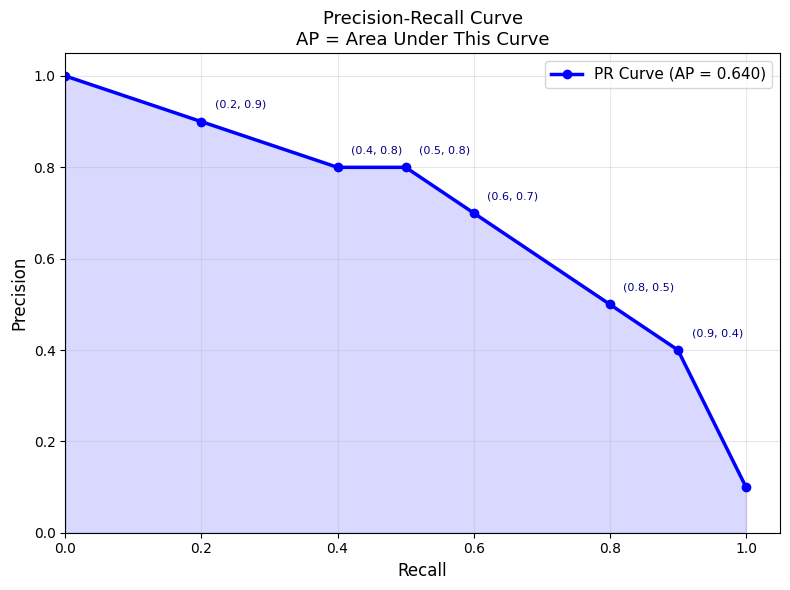


AP = 0.6400
(Area under the precision-recall curve)


In [6]:
import numpy as np
import matplotlib.pyplot as plt
from utils.metrics import compute_ap

# Manually build a PR curve to verify AP computation
# Simulate a decent detector
recalls    = np.array([0.0, 0.2, 0.4, 0.5, 0.6, 0.8, 0.9, 1.0])
precisions = np.array([1.0, 0.9, 0.8, 0.8, 0.7, 0.5, 0.4, 0.1])

ap = compute_ap(recalls, precisions)

# Plot the curve
fig, ax = plt.subplots(figsize=(8, 6))
ax.plot(recalls, precisions,
        color="blue", linewidth=2.5,
        marker="o", markersize=6,
        label=f"PR Curve (AP = {ap:.3f})")
ax.fill_between(recalls, precisions, alpha=0.15, color="blue")
ax.set_xlabel("Recall",    fontsize=12)
ax.set_ylabel("Precision", fontsize=12)
ax.set_title("Precision-Recall Curve\n"
             "AP = Area Under This Curve", fontsize=13)
ax.set_xlim(0, 1.05)
ax.set_ylim(0, 1.05)
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3)

# Annotate some points
for r, p in zip(recalls[1:-1], precisions[1:-1]):
    ax.annotate(f"({r:.1f}, {p:.1f})",
                xy=(r, p), xytext=(r+0.02, p+0.03),
                fontsize=8, color="navy")

plt.tight_layout()
plt.show()
print(f"\nAP = {ap:.4f}")
print("(Area under the precision-recall curve)")

In [7]:
# Test the summary formatter
fake_metrics = {
    "mAP": 0.342,
    "AP_per_class": {
        1: 0.45,   # person
        2: 0.21,   # bicycle
        3: 0.38,   # car
        4: 0.18,   # motorcycle
        5: 0.41,   # bus
        6: 0.35,   # truck
    }
}

fake_losses = {
    "loss_objectness":    0.312,
    "loss_rpn_box_reg":   0.156,
    "loss_classifier":    0.445,
    "loss_box_reg":       0.289,
}

summary = format_eval_summary(
    epoch   = 10,
    metrics = fake_metrics,
    losses  = fake_losses,
)
print(summary)


  Epoch 10 — Evaluation Summary

  Losses:
    loss_objectness           : 0.3120
    loss_rpn_box_reg          : 0.1560
    loss_classifier           : 0.4450
    loss_box_reg              : 0.2890
    Total                     : 1.2020

  Detection Metrics:
    mAP@0.50                  : 0.3420

  Per-class AP:
    person          0.4500  █████████
    bicycle         0.2100  ████
    car             0.3800  ███████
    motorcycle      0.1800  ███
    bus             0.4100  ████████
    truck           0.3500  ███████




In [8]:
checks = {}

# 1. Evaluator runs without error
checks["Evaluator runs without error"] = metrics is not None

# 2. Returns correct keys
checks["Returns mAP key"]              = "mAP" in metrics
checks["Returns AP_per_class key"]     = "AP_per_class" in metrics

# 3. mAP is in valid range
checks["mAP in range [0,1]"]           = 0.0 <= metrics["mAP"] <= 1.0

# 4. AP computed for all 6 classes
checks["AP for all 6 classes"]         = len(metrics["AP_per_class"]) == 6

# 5. PR curve AP computation works
ap_test = compute_ap(
    np.array([0.0, 0.5, 1.0]),
    np.array([1.0, 0.5, 0.0])
)
checks["AP computation works"]         = 0.0 <= ap_test <= 1.0

# 6. Format summary works
checks["Format summary works"]         = len(summary) > 50

# 7. Untrained model has low mAP
checks["Untrained model has low mAP"]  = metrics["mAP"] < 0.1

print("=== Step 7 Checklist ===\n")
all_passed = True
for check, passed in checks.items():
    icon = "✅" if passed else "❌"
    print(f"  {icon}  {check}")
    if not passed:
        all_passed = False

print()
if all_passed:
    print("All checks passed — ready for Step 8 (Inference)!")
else:
    print("Fix the failing checks before moving on.")

=== Step 7 Checklist ===

  ✅  Evaluator runs without error
  ✅  Returns mAP key
  ✅  Returns AP_per_class key
  ✅  mAP in range [0,1]
  ✅  AP for all 6 classes
  ✅  AP computation works
  ✅  Format summary works
  ✅  Untrained model has low mAP

All checks passed — ready for Step 8 (Inference)!
